In [1]:
from google.colab import files

print("📂 Faça o upload do arquivo Excel:")
uploaded = files.upload()

# Obter o nome do arquivo carregado
filename = list(uploaded.keys())[0]
print(f"✅ Arquivo carregado: {filename}")

📂 Faça o upload do arquivo Excel:


Saving 03-08 - Planilha de Gestão de Indicadores e Metas.xlsx to 03-08 - Planilha de Gestão de Indicadores e Metas.xlsx
✅ Arquivo carregado: 03-08 - Planilha de Gestão de Indicadores e Metas.xlsx


In [2]:
def limpar_aba(df, linhas_iniciais_pular=0, colunas_chave=None):
    """
    Remove linhas totalmente vazias e linhas onde colunas essenciais são nulas.

    Parâmetros:
    - df: DataFrame original
    - linhas_iniciais_pular: número de linhas a pular do início (já considerado no read_excel)
    - colunas_chave: lista de nomes de colunas que não podem ser nulas (se None, considera todas)
    """
    # Remover linhas totalmente vazias
    df_limpo = df.dropna(how='all')

    # Se colunas_chave for fornecido, remove linhas com NaN nessas colunas
    if colunas_chave is not None:
        df_limpo = df_limpo.dropna(subset=colunas_chave, how='all')

    # Resetar índice
    df_limpo = df_limpo.reset_index(drop=True)

    return df_limpo

In [7]:
import pandas as pd

xls = pd.ExcelFile(filename)

dados_limpos = {}
df_cadastro = pd.read_excel(xls, sheet_name='Cadastro', header=5)
df_cadastro = limpar_aba(df_cadastro, colunas_chave=['Resultado Líquido'])

# Remove a coluna 'Unnamed: 0' que está vazia e causa o erro de 'length mismatch'
df_cadastro = df_cadastro.drop(columns=['Unnamed: 0'])

df_cadastro.columns = ['Indicador', 'Tipo', 'Objetivo', 'Responsavel']
df_cadastro = df_cadastro.dropna(subset=['Indicador']).reset_index(drop=True)
dados_limpos['Cadastro'] = df_cadastro
print("📋 Cadastro limpo:")
display(df_cadastro)


df_acomp = pd.read_excel(xls, sheet_name='Acompanhamento', header=4)
df_acomp = limpar_aba(df_acomp, colunas_chave=['Indicador'])

# Remove a coluna 'Unnamed: 0' de df_acomp também, se existir
if 'Unnamed: 0' in df_acomp.columns:
    df_acomp = df_acomp.drop(columns=['Unnamed: 0'])

df_acomp.columns = ['Indicador', 'Ano_Mes', 'Mes', 'Meta', 'Valor', 'Valor_Ano_Anterior']
df_acomp = df_acomp.dropna(subset=['Indicador']).reset_index(drop=True)


for col in ['Meta', 'Valor', 'Valor_Ano_Anterior']:
    df_acomp[col] = pd.to_numeric(df_acomp[col], errors='coerce')


df_acomp['Ano_Mes'] = pd.to_datetime(df_acomp['Ano_Mes'], errors='coerce')
df_acomp['Ano'] = df_acomp['Ano_Mes'].dt.year
df_acomp['Mes'] = df_acomp['Ano_Mes'].dt.month
df_acomp['Mes_nome'] = df_acomp['Ano_Mes'].dt.strftime('%b')


df_acomp = df_acomp.sort_values(['Indicador', 'Ano_Mes']).reset_index(drop=True)
dados_limpos['Acompanhamento'] = df_acomp
print("\n📈 Acompanhamento limpo (primeiras linhas):")
display(df_acomp.head())



print("\n✅ Limpeza concluída!")

📋 Cadastro limpo:


,Indicador,Tipo,Objetivo,Responsavel
0,Satisfação dos Clientes,Porcentagem,Aumentar,"Jéssica, Gerente de Produto"
1,Custos Operacionais,Moeda,Diminuir,"Altair, Coordenador Financeiro"
2,Novos clientes,Número,Aumentar,"Felipe, Gerente Comercial"



📈 Acompanhamento limpo (primeiras linhas):


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,Indicador,Ano_Mes,Mes,Meta,Valor,Valor_Ano_Anterior,Ano,Mes_nome
0,Custos Operacionais,2023-01-01,1,600000.0,578847.0,515173.83,2023,Jan
1,Custos Operacionais,2023-02-01,2,600000.0,568572.0,670914.96,2023,Feb
2,Custos Operacionais,2023-03-01,3,600000.0,961589.0,1134675.02,2023,Mar
3,Custos Operacionais,2023-04-01,4,600000.0,104143.0,68734.38,2023,Apr
4,Custos Operacionais,2023-05-01,5,600000.0,689501.0,468860.68,2023,May



✅ Limpeza concluída!


In [8]:
# Resumo por indicador
resumo = df_acomp.groupby('Indicador').agg({
    'Valor': ['count', 'mean', 'sum', 'min', 'max'],
    'Meta': ['mean', 'sum'],
    'Valor_Ano_Anterior': ['mean', 'sum']
}).round(2)

resumo.columns = ['_'.join(col).strip() for col in resumo.columns.values]
resumo = resumo.reset_index()

# Adicionar % cumprimento médio da meta
resumo['%_Meta_Media'] = (resumo['Valor_mean'] / resumo['Meta_mean'] * 100).round(1)

print("📊 Resumo dos indicadores:")
display(resumo)

📊 Resumo dos indicadores:


,Indicador,Valor_count,Valor_mean,Valor_sum,Valor_min,Valor_max,Meta_mean,Meta_sum,Valor_Ano_Anterior_mean,Valor_Ano_Anterior_sum,%_Meta_Media
0,Custos Operacionais,12,531662.50,6379950.0,104143.0,1090205.0,600000.0,7200000.0,526576.07,6318912.85,88.6
1,Novos clientes,12,1153.58,13843.0,199.0,1659.0,1150.0,13800.0,1048.52,12582.29,100.3
2,Resultado Líquido,12,1889943.50,22679322.0,1022902.0,2460768.0,1750000.0,21000000.0,1749712.05,20996544.59,108.0
3,Satisfação dos Clientes,12,79.33,952.0,65.0,90.0,75.0,900.0,68.74,824.84,105.8


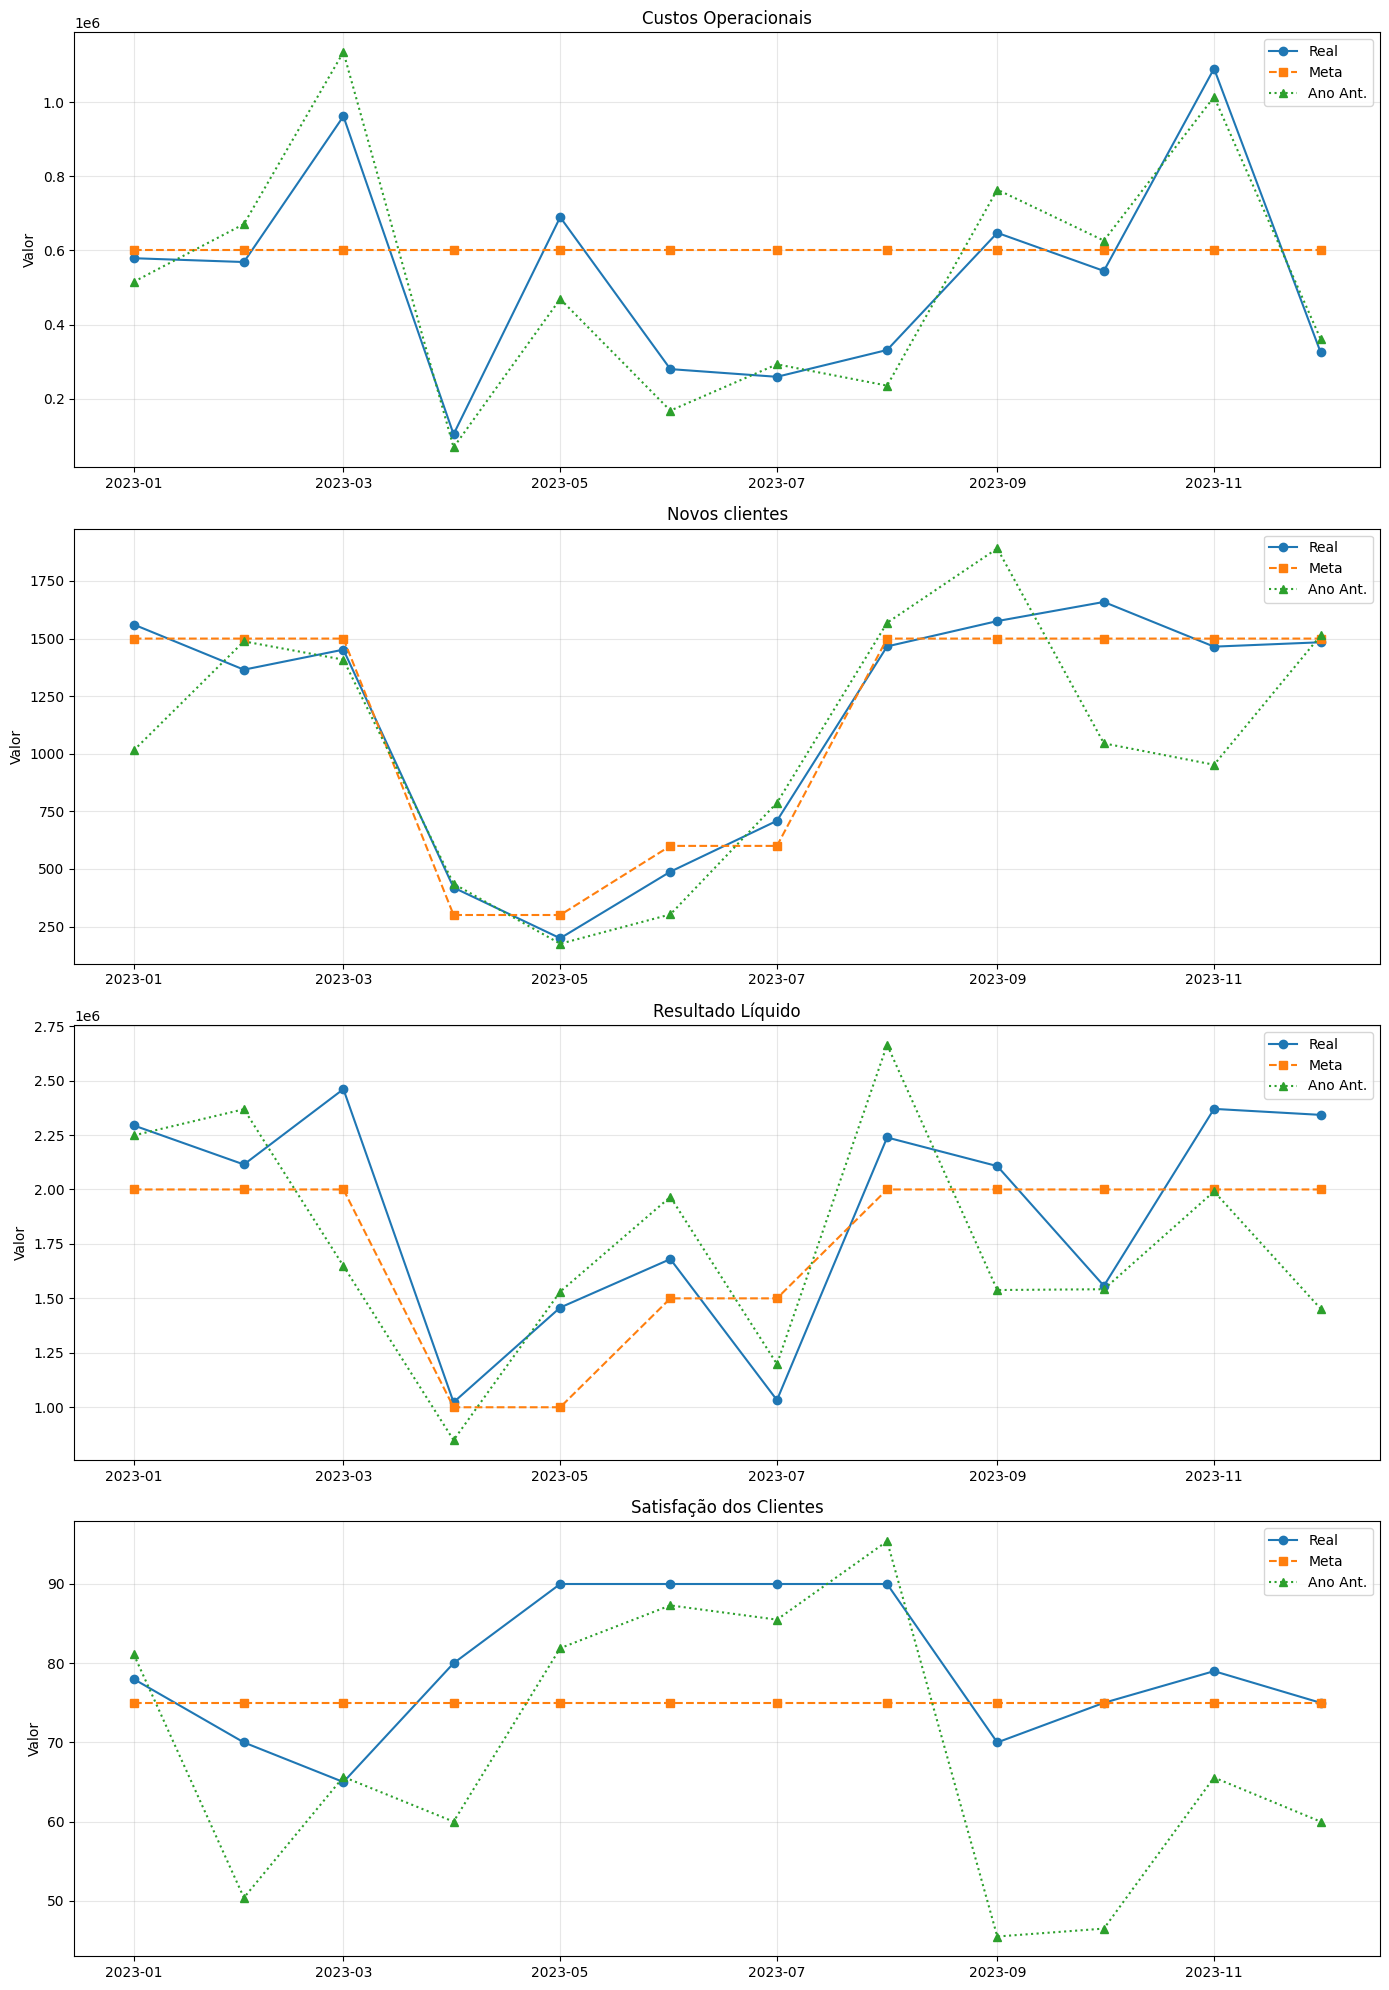

In [10]:
import matplotlib.pyplot as plt

# Gráfico de linha para cada indicador
indicadores = df_acomp['Indicador'].unique()
n = len(indicadores)

fig, axes = plt.subplots(n, 1, figsize=(14, 5*n))
if n == 1:
    axes = [axes]

for i, ind in enumerate(indicadores):
    df_ind = df_acomp[df_acomp['Indicador'] == ind].copy()
    df_ind = df_ind.sort_values('Ano_Mes')

    ax = axes[i]
    ax.plot(df_ind['Ano_Mes'], df_ind['Valor'], marker='o', label='Real', color='#1f77b4')
    ax.plot(df_ind['Ano_Mes'], df_ind['Meta'], marker='s', linestyle='--', label='Meta', color='#ff7f0e')
    ax.plot(df_ind['Ano_Mes'], df_ind['Valor_Ano_Anterior'], marker='^', linestyle=':', label='Ano Ant.', color='#2ca02c')

    ax.set_title(f'{ind}')
    ax.set_ylabel('Valor')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

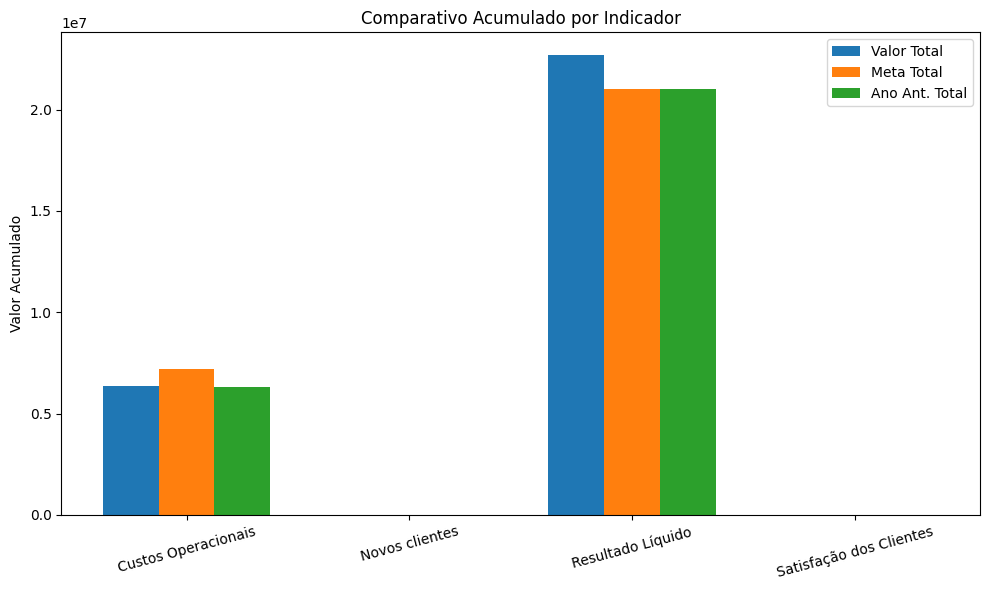

,Indicador,Valor,Meta,Valor_Ano_Anterior,%_Meta
0,Custos Operacionais,6379950.0,7200000.0,6318912.85,88.6
1,Novos clientes,13843.0,13800.0,12582.29,100.3
2,Resultado Líquido,22679322.0,21000000.0,20996544.59,108.0
3,Satisfação dos Clientes,952.0,900.0,824.84,105.8


In [17]:
import numpy as np
import matplotlib.pyplot as plt

totais = df_acomp.groupby('Indicador').agg({
    'Valor': 'sum',
    'Meta': 'sum',
    'Valor_Ano_Anterior': 'sum'
}).reset_index()

totais['%_Meta'] = (totais['Valor'] / totais['Meta'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(totais))
width = 0.25

ax.bar(x - width, totais['Valor'], width, label='Valor Total')
ax.bar(x, totais['Meta'], width, label='Meta Total')
ax.bar(x + width, totais['Valor_Ano_Anterior'], width, label='Ano Ant. Total')

ax.set_xticks(x)
ax.set_xticklabels(totais['Indicador'], rotation=15)
ax.set_ylabel('Valor Acumulado')
ax.set_title('Comparativo Acumulado por Indicador')
ax.legend()

plt.tight_layout()
plt.show()

display(totais)